# Benchmark: AutoCarver vs. optbinning vs. KBinsDiscretizer

This notebook runs the three binning libraries side-by-side on two public datasets:

1. **German Credit** — binary classification, mixed numeric / categorical features, 1,000 rows.
2. **California Housing** — regression, all-numeric features, 20,640 rows.

For each library and dataset, we report:

- **`fit` and `transform` wall-clock** (seconds)
- **Downstream-model score** — AUC for binary, R² for regression — using a linear model (logistic regression / ridge) on the one-hot-encoded bin output
- **`train` → `test` score drop** as a coarse proxy for drift sensitivity

All three libraries see the same `train + dev` data and are evaluated on the same held-out `test`. AutoCarver uses the dev sample for its built-in robustness veto; optbinning and KBinsDiscretizer don't have a dev-set concept and so treat the union of train + dev as one pooled training set — which is the comparison practitioners actually run.

**This is not an IV / Tschuprow's T leaderboard.** Those metrics structurally favour the library whose objective they are. The downstream-model score is the metric a real scorecard team would use to pick a binner.

Numbers come from a single run on a single machine with a fixed seed; treat them as illustrative, not as authoritative benchmark figures. Re-run on your own data before drawing conclusions.

## Setup

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, fetch_openml
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer

from AutoCarver import BinaryCarver, ContinuousCarver, Features
from AutoCarver.discretizers.utils.base_discretizer import ProcessingConfig

try:
    from optbinning import ContinuousOptimalBinning, OptimalBinning

    HAS_OPTBINNING = True
except ImportError:
    HAS_OPTBINNING = False
    print('optbinning is not installed \u2014 its rows will be skipped.')

SEED = 42
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 3.5)

In [2]:
def one_hot(df):
    """Treat every bin label as a categorical level and one-hot encode it.

    Lets a linear downstream model consume any of the three libraries' outputs
    uniformly, without us computing WoE per bin.
    """
    return pd.get_dummies(df.astype(str), drop_first=True).astype(float)


def fit_eval_binary(X_train, X_test, y_train, y_test):
    Xtr = one_hot(X_train)
    Xte = one_hot(X_test).reindex(columns=Xtr.columns, fill_value=0.0)
    model = LogisticRegression(max_iter=1000, random_state=SEED).fit(Xtr, y_train)
    return {
        'train_auc': roc_auc_score(y_train, model.predict_proba(Xtr)[:, 1]),
        'test_auc': roc_auc_score(y_test, model.predict_proba(Xte)[:, 1]),
    }


def fit_eval_regression(X_train, X_test, y_train, y_test):
    Xtr = one_hot(X_train)
    Xte = one_hot(X_test).reindex(columns=Xtr.columns, fill_value=0.0)
    model = Ridge(random_state=SEED).fit(Xtr, y_train)
    return {
        'train_r2': r2_score(y_train, model.predict(Xtr)),
        'test_r2': r2_score(y_test, model.predict(Xte)),
    }


def plot_bars(results_df, score_cols, title):
    fig, axes = plt.subplots(1, len(score_cols), figsize=(4 * len(score_cols), 3.5))
    if len(score_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, score_cols):
        results_df.plot.bar(x='library', y=col, ax=ax, legend=False, color='#4C72B0')
        ax.set_title(col)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=0)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

In [3]:
from AutoCarver.combinations.binary import CramervCombinations

MAX_N_MOD = 5
MIN_FREQ = 0.05

def bin_with_autocarver(X_train, y_train, X_dev, y_dev, X_test, categoricals, quantitatives, kind):
    Carver = BinaryCarver if kind == 'binary' else ContinuousCarver
    features = Features(categoricals=categoricals, numericals=quantitatives)
    config = ProcessingConfig(verbose=False, dropna=False, ordinal_encoding=False)  # showing statistics
    combination_evaluator = CramervCombinations() if kind == 'binary' else None
    carver = Carver(features=features, min_freq=MIN_FREQ, max_n_mod=MAX_N_MOD, config=config,combination_evaluator=combination_evaluator)

    t0 = time.perf_counter()
    X_tr = carver.fit_transform(X_train.copy(), y_train, X_dev=X_dev.copy(), y_dev=y_dev)
    fit_t = time.perf_counter() - t0

    X_dv = carver.transform(X_dev.copy())
    t1 = time.perf_counter()
    X_te = carver.transform(X_test.copy())
    transform_t = time.perf_counter() - t1
    return pd.concat([X_tr, X_dv]), X_te, fit_t, transform_t, carver


def bin_with_optbinning(X_train, y_train, X_dev, y_dev, X_test, categoricals, quantitatives, kind):
    Cls = OptimalBinning if kind == 'binary' else ContinuousOptimalBinning
    X_all = pd.concat([X_train, X_dev])
    y_all = pd.concat([y_train, y_dev])
    binners = {}
    train_binned = pd.DataFrame(index=X_all.index)
    test_binned = pd.DataFrame(index=X_test.index)

    t0 = time.perf_counter()
    for col in X_all.columns:
        dtype = 'categorical' if col in categoricals else 'numerical'
        binner = Cls(name=col, dtype=dtype, min_prebin_size=MIN_FREQ/2, max_n_bins=MAX_N_MOD)
        binner.fit(X_all[col].to_numpy(), y_all.to_numpy())
        binners[col] = binner
        train_binned[col] = binner.transform(X_all[col].to_numpy(), metric='bins')
    fit_t = time.perf_counter() - t0

    t1 = time.perf_counter()
    for col, b in binners.items():
        test_binned[col] = b.transform(X_test[col].to_numpy(), metric='bins')
    transform_t = time.perf_counter() - t1
    return train_binned, test_binned, fit_t, transform_t, binners


def bin_with_kbins(X_train, X_dev, X_test, categoricals, quantitatives, n_bins=5):
    X_all = pd.concat([X_train, X_dev])
    num_train = X_all[quantitatives].apply(lambda c: c.fillna(c.median()))
    num_test = X_test[quantitatives].apply(lambda c: c.fillna(c.median()))
    kbd = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')

    t0 = time.perf_counter()
    binned_num_train = pd.DataFrame(
        kbd.fit_transform(num_train), columns=quantitatives, index=X_all.index
    )
    fit_t = time.perf_counter() - t0

    t1 = time.perf_counter()
    binned_num_test = pd.DataFrame(
        kbd.transform(num_test), columns=quantitatives, index=X_test.index
    )
    transform_t = time.perf_counter() - t1

    # KBins has no opinion on categoricals — pass them through as labels
    train = pd.concat([binned_num_train, X_all[categoricals].astype(str)], axis=1)
    test = pd.concat([binned_num_test, X_test[categoricals].astype(str)], axis=1)
    return train, test, fit_t, transform_t, kbd

## Binary classification — German Credit

20 features (numeric + categorical), 1,000 rows, target = `class == 'bad'`. Train / dev / test split = 60 / 20 / 20 %.

In [4]:
credit = fetch_openml(data_id=31, as_frame=True)
df = credit.frame.copy()

y_binary = (df['class'] == 'bad').astype(int)
X_binary = df.drop(columns=['class'])

X_train, X_rest, y_train, y_rest = train_test_split(
    X_binary, y_binary, test_size=0.4, random_state=SEED, stratify=y_binary,
)
X_dev, X_test, y_dev, y_test = train_test_split(
    X_rest, y_rest, test_size=0.5, random_state=SEED, stratify=y_rest,
)

categoricals = [c for c in X_binary.columns if X_binary[c].dtype == object or isinstance(X_binary[c].dtype, pd.CategoricalDtype)]
quantitatives = [c for c in X_binary.columns if c not in categoricals]

print(f'train={len(X_train)}, dev={len(X_dev)}, test={len(X_test)}')
print(f'categoricals={len(categoricals)}, numericals={len(quantitatives)}')
print(f'bad rate (train)={y_train.mean():.3f}, (test)={y_test.mean():.3f}')

train=600, dev=200, test=200
categoricals=13, numericals=7
bad rate (train)=0.300, (test)=0.300


In [5]:
y_train_full = pd.concat([y_train, y_dev])

runs = [(
    'AutoCarver',
    lambda: bin_with_autocarver(X_train, y_train, X_dev, y_dev, X_test, categoricals, quantitatives, 'binary'),
)]
if HAS_OPTBINNING:
    runs.append((
        'optbinning',
        lambda: bin_with_optbinning(X_train, y_train, X_dev, y_dev, X_test, categoricals, quantitatives, 'binary'),
    ))
runs.append((
    'KBinsDiscretizer',
    lambda: bin_with_kbins(X_train, X_dev, X_test, categoricals, quantitatives),
))

rows = []
for name, run in runs:
    X_tr, X_te, fit_t, transform_t, carver = run()
    scores = fit_eval_binary(X_tr, X_te, y_train_full, y_test)
    rows.append({
        'library': name,
        'fit_s': round(fit_t, 3),
        'transform_s': round(transform_t, 4),
        'train_auc': round(scores['train_auc'], 4),
        'test_auc': round(scores['test_auc'], 4),
        'auc_drop': round(scores['train_auc'] - scores['test_auc'], 4),
    })

binary_results = pd.DataFrame(rows)
binary_results

,library,fit_s,transform_s,train_auc,test_auc,auc_drop
0,AutoCarver,1.317,0.0108,0.8496,0.8044,0.0451
1,optbinning,1.029,0.0245,0.8523,0.7931,0.0592
2,KBinsDiscretizer,0.005,0.0011,0.8401,0.7943,0.0458


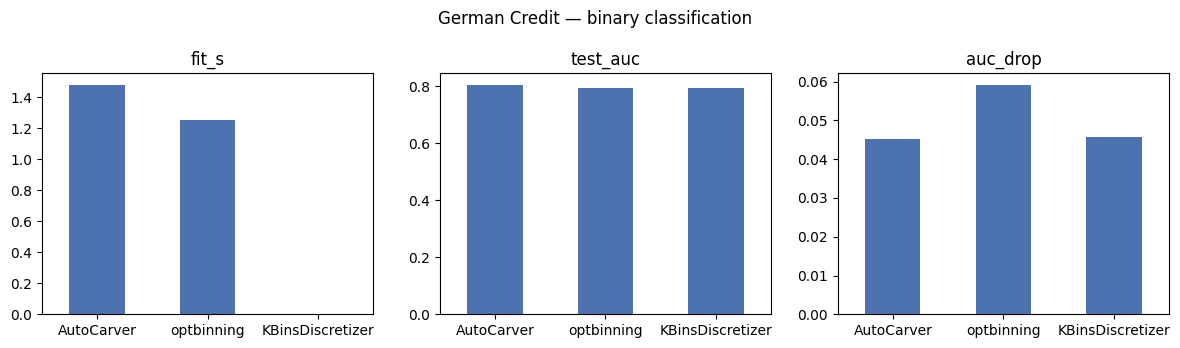

In [6]:
plot_bars(binary_results, ['fit_s', 'test_auc', 'auc_drop'], 'German Credit \u2014 binary classification')

## Regression — California Housing

6 numeric demographic features (Latitude / Longitude dropped — see comment in the next cell), 20,640 rows, target = median house value. Same 60 / 20 / 20 split.

In [7]:
housing = fetch_california_housing(as_frame=True)
X_reg = housing.frame.drop(columns=['MedHouseVal'])
y_reg = housing.frame['MedHouseVal']

X_train, X_rest, y_train, y_rest = train_test_split(X_reg, y_reg, test_size=0.4, random_state=SEED)
X_dev, X_test, y_dev, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=SEED)

quantitatives = list(X_reg.columns)
categoricals = []

print(f'train={len(X_train)}, dev={len(X_dev)}, test={len(X_test)}')
print(f'numericals={len(quantitatives)} ({quantitatives})')

train=12384, dev=4128, test=4128
numericals=8 (['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'])


In [8]:
y_train_full = pd.concat([y_train, y_dev])

runs = [(
    'AutoCarver',
    lambda: bin_with_autocarver(X_train, y_train, X_dev, y_dev, X_test, categoricals, quantitatives, 'continuous'),
)]
if HAS_OPTBINNING:
    runs.append((
        'optbinning',
        lambda: bin_with_optbinning(X_train, y_train, X_dev, y_dev, X_test, categoricals, quantitatives, 'continuous'),
    ))
runs.append((
    'KBinsDiscretizer',
    lambda: bin_with_kbins(X_train, X_dev, X_test, categoricals, quantitatives),
))

rows = []
for name, run in runs:
    X_tr, X_te, fit_t, transform_t, carver = run()
    scores = fit_eval_regression(X_tr, X_te, y_train_full, y_test)
    rows.append({
        'library': name,
        'fit_s': round(fit_t, 3),
        'transform_s': round(transform_t, 4),
        'train_r2': round(scores['train_r2'], 4),
        'test_r2': round(scores['test_r2'], 4),
        'r2_drop': round(scores['train_r2'] - scores['test_r2'], 4),
    })

regression_results = pd.DataFrame(rows)
regression_results

,library,fit_s,transform_s,train_r2,test_r2,r2_drop
0,AutoCarver,6.649,0.0969,0.6652,0.6595,0.0057
1,optbinning,2.883,0.0097,0.5145,0.5077,0.0068
2,KBinsDiscretizer,0.012,0.0026,0.6181,0.6192,-0.0011


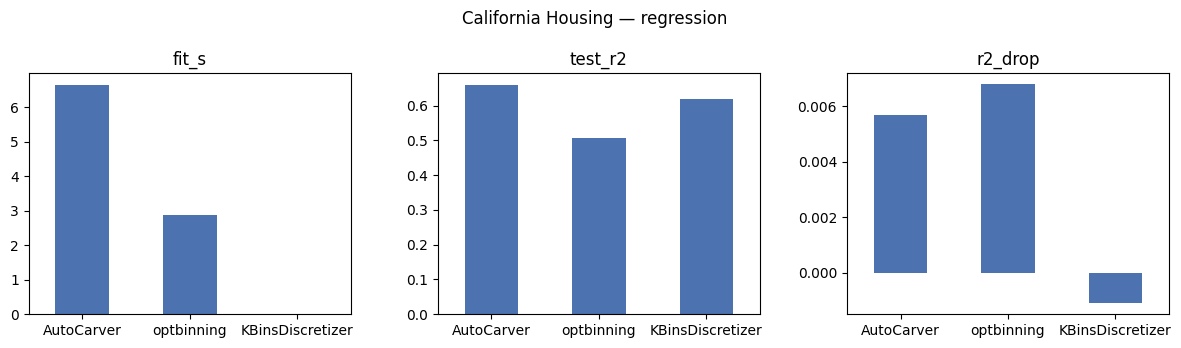

In [9]:
plot_bars(regression_results, ['fit_s', 'test_r2', 'r2_drop'], 'California Housing \u2014 regression')

## How to read these numbers

- **`fit_s` / `transform_s`** measure only `.fit` / `.transform` wall-clock — not data loading, not one-hot encoding, not the downstream model.
- **`test_auc` / `test_r2`** are the headline metric. They reflect how well a *simple* downstream model performs on each library's binned output. A tree-based downstream model would tell a different (and less binning-sensitive) story.
- **`auc_drop` / `r2_drop`** are `train - test` and measure how much each library's bins overfit. Lower is more robust. AutoCarver's dev-set veto is designed to keep this small.
- **Same data, same seed, same downstream model** across libraries — but a single run, on one machine, with one set of hyper-parameters. Treat as illustrative.

## When the result will move

- **Bigger `max_n_mod` / smaller `min_freq`** will improve AutoCarver and optbinning's in-sample scores at the cost of `*_drop`. KBins doesn't have a target, so it's mostly insensitive.
- **Different downstream model.** Gradient-boosted trees on the raw features beat any binning + linear pipeline. The point of binning is interpretability, not raw accuracy.
- **Different dataset.** German Credit is small; on a 10M-row credit-risk dataset, `fit_s` is what dominates the comparison.

See [comparison.rst](../../comparison.html) for the qualitative scope and algorithmic comparison.